# 01 - Unicorn geography and sector

**Research question.** Among companies on public unicorn lists today, how is the population split across sectors and geographies, and how has the sector mix shifted across cohorts of *becoming* a unicorn?

**Data source.** CB Insights public unicorn tracker - <https://www.cbinsights.com/research-unicorn-companies> - pulled via `scripts/fetch_data.py`. Pull date and source recorded in `data/raw/_fetch_log.json`.

**Key caveats up front.**
- This is a list of *surviving unicorns*, not a random sample of   startups. Anything we say about "unicorns" is conditional on having   crossed $1B and on the tracker not having removed the company.
- `country` is HQ location at listing time, not founder origin or   incorporation.
- Sector labels come from CB Insights' own taxonomy. We keep their   labels and only collapse "Industrial" / "Industrials" duplicates.
- CB Insights does not publish founding year, so cohort analysis here   uses **year of becoming a unicorn**, not year of founding.


## Reproducibility

The cell below records the package versions and the data-pull metadata that produced everything below. It also installs a hook so every `plt.show()` call also writes the figure to `notebooks/figures/` — that way the PNGs on GitHub are always in sync with the rendered notebook.

In [1]:
# Reproducibility
from __future__ import annotations
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
_log = Path('..') / 'data' / 'raw' / '_fetch_log.json'
_meta = json.loads(_log.read_text())[-1] if _log.exists() else {'date': 'unknown', 'source': 'unknown'}
print(f'python      : {sys.version.split()[0]}')
print(f'pandas      : {pd.__version__}')
print(f'numpy       : {np.__version__}')
print(f'matplotlib  : {matplotlib.__version__}')
print(f'data source : {_meta.get("source")}')
print(f'pull date   : {_meta.get("date")}')
print('notebook    : 01_unicorn_geography_and_sector')

_FIG_SLUG = '01_unicorn_geography_and_sector'
_FIG_DIR = Path('figures'); _FIG_DIR.mkdir(parents=True, exist_ok=True)
_FIG_COUNTER = {'n': 0}
_orig_show = plt.show
def _show_and_save(*a, **kw):
    for num in plt.get_fignums():
        _FIG_COUNTER['n'] += 1
        fig = plt.figure(num)
        out = _FIG_DIR / f'{_FIG_SLUG}_fig{_FIG_COUNTER["n"]}.png'
        fig.savefig(out, dpi=140, bbox_inches='tight')
    return _orig_show(*a, **kw)
plt.show = _show_and_save


python      : 3.10.12
pandas      : 2.3.3
numpy       : 2.2.6
matplotlib  : 3.10.8
data source : cbinsights
pull date   : 2026-05-16
notebook    : 01_unicorn_geography_and_sector


In [2]:
from __future__ import annotations
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid', context='talk')
pd.options.display.max_columns = 50


## 1. Load the public unicorn list

If `data/raw/unicorns.csv` is missing, run from the repo root:

```bash
python scripts/fetch_data.py
```


In [3]:
RAW = Path('..') / 'data' / 'raw' / 'unicorns.csv'
LOG = Path('..') / 'data' / 'raw' / '_fetch_log.json'

if not RAW.exists():
    raise FileNotFoundError(
        f'{RAW} not found. Run `python scripts/fetch_data.py` from the repo root.'
    )

df = pd.read_csv(RAW)
pull_meta = json.loads(LOG.read_text())[-1] if LOG.exists() else {'date': 'unknown', 'source': 'unknown'}
print(f"Loaded {len(df):,} rows from {pull_meta['source']} (pulled {pull_meta['date']}).")
print('Columns:', list(df.columns))
df.head()


Loaded 1,356 rows from cbinsights (pulled 2026-05-16).
Columns: ['company', 'valuation_usd_b', 'unicorn_year', 'country', 'City', 'sector', 'select_investors']


,company,valuation_usd_b,unicorn_year,country,City,sector,select_investors
0,OpenAI,$840,2019,United States,San Francisco,Enterprise Tech,"Khosla Ventures, Thrive Capital, Sequoia Capital"
1,ByteDance,$480,2017,China,Beijing,Media & Entertainment,"Sequoia Capital China, SIG Asia Investments, S..."
2,SpaceX,$400,2012,United States,Hawthorne,Industrials,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
3,Anthropic,$380,2023,United States,San Francisco,Enterprise Tech,Google
4,Stripe,$159,2014,United States,San Francisco,Financial Services,"Khosla Ventures, LowercaseCapital, capitalG"


## 2. Coarse region and sector buckets


In [4]:
REGION_MAP = {
    'United States': 'US',
    'China': 'CN', 'Hong Kong': 'CN',
    'India': 'IN',
    'United Kingdom': 'EU', 'Germany': 'EU', 'France': 'EU',
    'Sweden': 'EU', 'Netherlands': 'EU', 'Spain': 'EU', 'Ireland': 'EU',
    'Switzerland': 'EU', 'Estonia': 'EU', 'Finland': 'EU', 'Denmark': 'EU',
    'Norway': 'EU', 'Italy': 'EU', 'Belgium': 'EU', 'Austria': 'EU',
    'Portugal': 'EU', 'Luxembourg': 'EU', 'Czech Republic': 'EU',
}

def to_region(c):
    if pd.isna(c):
        return 'Other'
    return REGION_MAP.get(str(c).strip(), 'Other')

SECTOR_MAP = {
    'Enterprise Tech': 'Enterprise Tech',
    'Financial Services': 'Fintech',
    'Consumer & Retail': 'Consumer/Retail',
    'Industrials': 'Industrials',
    'Healthcare & Life Sciences': 'Healthcare',
    'Media & Entertainment': 'Media/Entertainment',
    'Insurance': 'Insurance',
    'Industrial': 'Industrials',
}

def to_sector(s):
    if pd.isna(s):
        return 'Other'
    return SECTOR_MAP.get(str(s).strip(), 'Other')

df['region'] = df['country'].apply(to_region)
df['sector_grp'] = df['sector'].apply(to_sector)
df[['company', 'country', 'region', 'sector', 'sector_grp']].head(10)


,company,country,region,sector,sector_grp
0,OpenAI,United States,US,Enterprise Tech,Enterprise Tech
1,ByteDance,China,CN,Media & Entertainment,Media/Entertainment
2,SpaceX,United States,US,Industrials,Industrials
3,Anthropic,United States,US,Enterprise Tech,Enterprise Tech
4,Stripe,United States,US,Financial Services,Fintech
5,Databricks,United States,US,Enterprise Tech,Enterprise Tech
6,VAST Data,United States,US,Enterprise Tech,Enterprise Tech
7,Revolut,United Kingdom,EU,Financial Services,Fintech
8,SHEIN,Singapore,Other,Consumer & Retail,Consumer/Retail
9,Ripple,United States,US,Financial Services,Fintech


## 3. Sector mix by year-of-becoming-unicorn cohort

We bin `unicorn_year` into four cohorts: pre-2014, 2014-2017, 2018-2020 (the late-cycle wave), 2021+ (post-ZIRP froth and after).


In [5]:
df['unicorn_year_num'] = pd.to_numeric(df['unicorn_year'], errors='coerce')
cohorts = pd.cut(
    df['unicorn_year_num'],
    bins=[-np.inf, 2013, 2017, 2020, np.inf],
    labels=['pre-2014', '2014-2017', '2018-2020', '2021+'],
)
df['unicorn_cohort'] = cohorts

pivot = (
    df.dropna(subset=['unicorn_cohort'])
      .groupby(['unicorn_cohort', 'sector_grp'], observed=True)
      .size()
      .unstack(fill_value=0)
)
share = pivot.div(pivot.sum(axis=1), axis=0)
share.round(3)


sector_grp,Consumer/Retail,Enterprise Tech,Fintech,Healthcare,Industrials,Insurance,Media/Entertainment,Other
unicorn_cohort,,,,,,,,
pre-2014,0.375,0.250,0.125,0.000,0.125,0.000,0.125,0.000
2014-2017,0.420,0.136,0.102,0.057,0.114,0.011,0.159,0.000
2018-2020,0.217,0.291,0.140,0.089,0.190,0.019,0.054,0.000
2021+,0.112,0.395,0.181,0.099,0.143,0.017,0.052,0.002


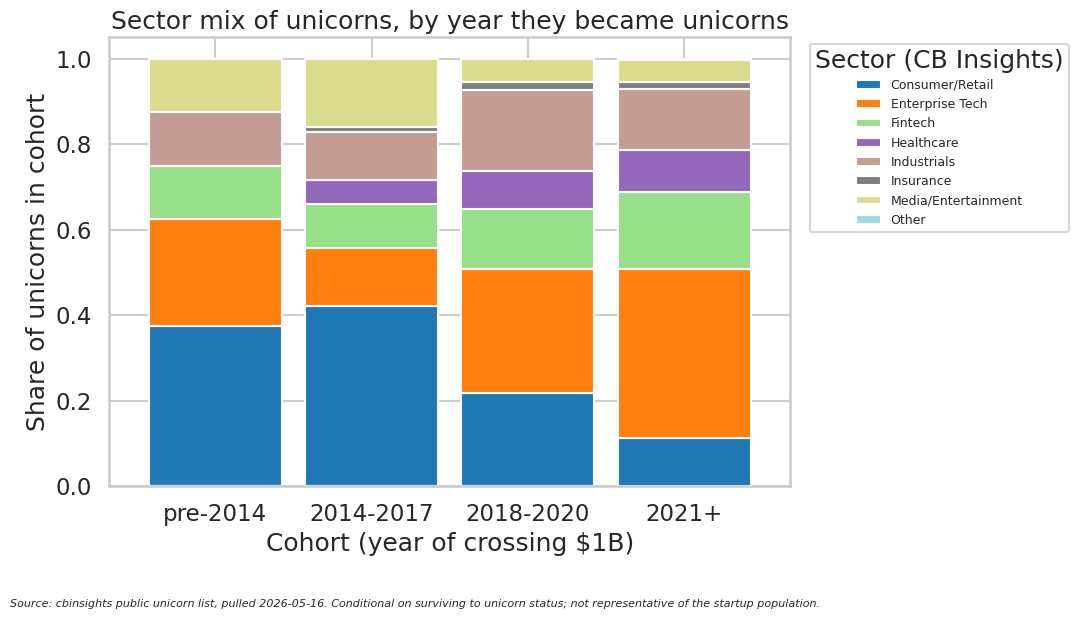

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
share.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.85)
ax.set_title('Sector mix of unicorns, by year they became unicorns')
ax.set_xlabel('Cohort (year of crossing $1B)')
ax.set_ylabel('Share of unicorns in cohort')
ax.legend(title='Sector (CB Insights)', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=0)
fig.text(0.01, -0.04,
         f"Source: {pull_meta['source']} public unicorn list, pulled {pull_meta['date']}. "
         'Conditional on surviving to unicorn status; not representative of the startup population.',
         fontsize=8, style='italic')
plt.tight_layout()
plt.show()


## 4. Geographic concentration


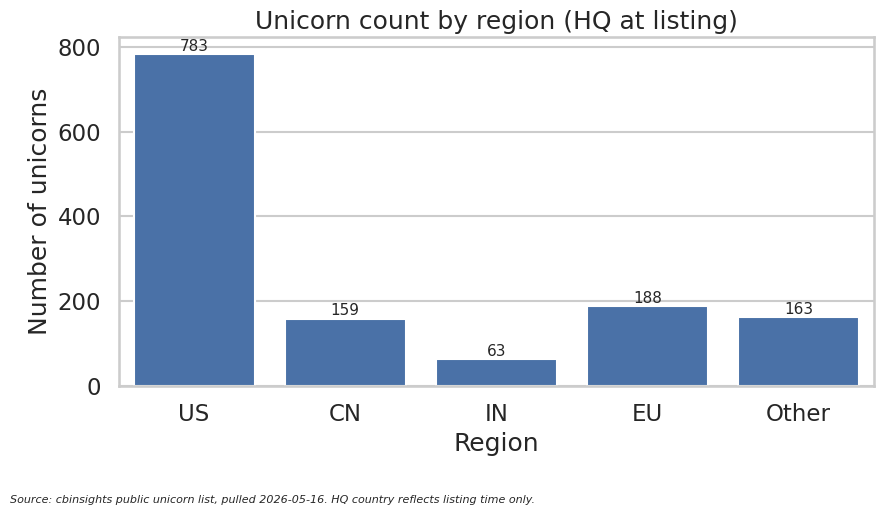

In [7]:
region_counts = (
    df['region'].value_counts()
      .reindex(['US', 'CN', 'IN', 'EU', 'Other']).fillna(0).astype(int)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=region_counts.index, y=region_counts.values, ax=ax, color='#3b6fb6')
for i, v in enumerate(region_counts.values):
    ax.text(i, v + max(region_counts.values) * 0.01, f'{v:,}', ha='center', fontsize=11)
ax.set_title('Unicorn count by region (HQ at listing)')
ax.set_xlabel('Region')
ax.set_ylabel('Number of unicorns')
fig.text(0.01, -0.04,
         f"Source: {pull_meta['source']} public unicorn list, pulled {pull_meta['date']}. "
         'HQ country reflects listing time only.',
         fontsize=8, style='italic')
plt.tight_layout()
plt.show()


## 5. Sector x geography heatmap (interactive)

Row-normalized so each region sums to 100%. This is the sector *composition within a region*, not absolute counts.


In [8]:
heat = (
    df.groupby(['region', 'sector_grp'])
      .size()
      .unstack(fill_value=0)
      .reindex(['US', 'CN', 'IN', 'EU', 'Other'])
)
heat_share = heat.div(heat.sum(axis=1), axis=0).round(3)

fig = px.imshow(
    heat_share.values,
    x=list(heat_share.columns),
    y=list(heat_share.index),
    color_continuous_scale='Blues',
    aspect='auto',
    labels=dict(x='Sector', y='Region', color='Share of region'),
    title='Sector composition within each region (row-normalized)',
    text_auto='.0%',
)
fig.update_layout(
    margin=dict(l=70, r=20, t=60, b=90),
    annotations=[dict(
        text=f"Source: {pull_meta['source']} public unicorn list, pulled {pull_meta['date']}.",
        xref='paper', yref='paper', x=0, y=-0.22, showarrow=False,
        font=dict(size=10, color='gray'),
    )],
)
fig.show()


## What this cannot tell us

- **Base rates.** We see sectors and geographies of *surviving   unicorns*, not of all founded startups. A small region here could   reflect either few startups or a low conditional unicorn rate -   we cannot distinguish these from this data alone.
- **Time of measurement.** This is a snapshot. Companies that crossed   $1B and quietly fell below it are handled inconsistently by the   tracker; "paper unicorns" with stale 2021 marks remain on the list.
- **No founding-year cohorts.** CB Insights does not publish a founding   year. The cohort axis here is *year of becoming a unicorn*, which   conflates company age with funding-market timing.
- **Sector taxonomy.** Labels are CB Insights' own; we did not re-code   from product descriptions. A serious sector cut would.
- **No outcomes.** Nothing here speaks to returns, exits, or failures.


## Save figures

Figures are auto-persisted by the `plt.show` hook installed in the Reproducibility cell at the top. The cell below just lists what was written so the run is self-documenting. Plotly figures are interactive and not exported here.

In [9]:
# Save key figures
from pathlib import Path
_slug = '01_unicorn_geography_and_sector'
_written = sorted(Path('figures').glob(f'{_slug}_fig*.png'))
print(f'{len(_written)} figure(s) saved to notebooks/figures/ for {_slug}:')
for p in _written:
    print(f'  {p}')


2 figure(s) saved to notebooks/figures/ for 01_unicorn_geography_and_sector:
  figures/01_unicorn_geography_and_sector_fig1.png
  figures/01_unicorn_geography_and_sector_fig2.png
